<a href="https://colab.research.google.com/github/Pradeep-Kumar-Panga/DecodingComplexities/blob/main/The_Machines_Compass_Calculus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Engineering Lab: The Machine's Compass
**Decoding the Math of Optimization: Why AI Needs Calculus**

In Machine Learning, training a model is like dropping a blindfolded robot onto a massive mountain and telling it to find the absolute lowest point (minimum error).

To do this, the machine needs a compass to tell it which way is "down." It needs to find the **slope** of the mountain.

In this lab, we will prove why trying to calculate this slope using basic computer code (Numerical Differentiation) will eventually crash your training loop, and why **Calculus** (Analytical Differentiation) is the ultimate software optimization.

📺 **Watch the full video breakdown on YouTube:** https://youtu.be/J4dYGgyd1d4  
📖 **Read the companion deep-dive on the blog:** https://www.pradeeppanga.com/2026/04/calculus-machine-learning.html

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for high-contrast, professional plots
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Part 1: The Loss Mountain
First, let's build the simplest loss landscape possible. Imagine our Neural Network's Error (Loss) is simply the weight parameter squared: `Loss = w²`.

Our robot is currently standing high up on the mountain at a weight of `3.0`. Its goal is to reach the bottom (`0.0`).

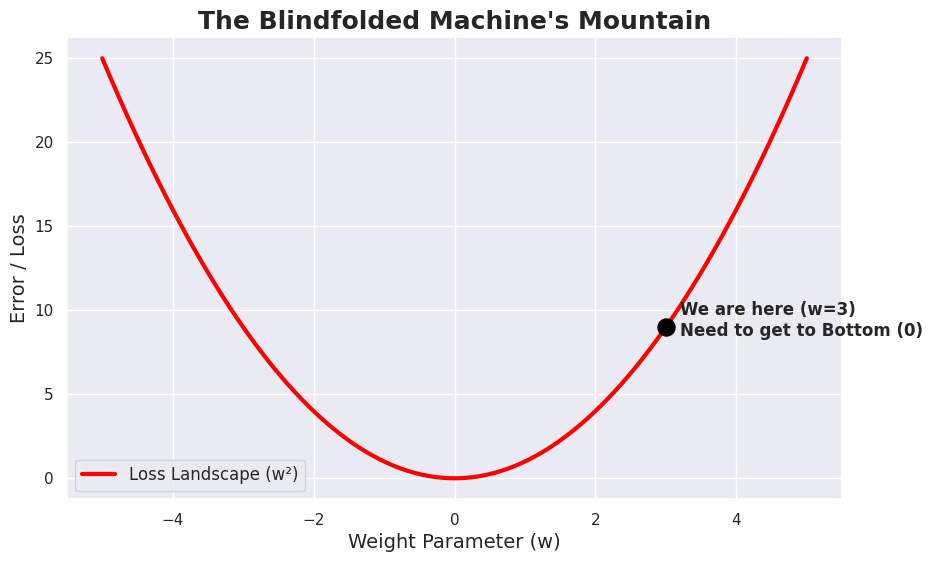

In [ ]:
def calculate_loss(w):
    return w**2

weights = np.linspace(-5, 5, 100)
loss = calculate_loss(weights)

current_weight = 3.0
current_loss = calculate_loss(current_weight)

# Visualize the mountain and our blindfolded robot
plt.figure()
plt.plot(weights, loss, color='red', linewidth=3, label="Loss Landscape (w²)")
plt.scatter([current_weight], [current_loss], color='black', s=150, zorder=5)
plt.text(3.2, 8.5, "We are here (w=3)\nNeed to get to Bottom (0)", fontsize=12, fontweight='bold')

plt.title("The Blindfolded Machine's Mountain", fontsize=18, fontweight='bold')
plt.xlabel("Weight Parameter (w)", fontsize=14)
plt.ylabel("Error / Loss", fontsize=14)
plt.legend(fontsize=12)
plt.show()

### Part 2: The Naive Approach (Guessing the Slope)
If we don't know Calculus, how do we program a computer to find the slope?

We use basic geometry: **Rise over Run**.
We tell the computer to take a tiny step forward (`h`), measure the change in height, and divide by the step size.

In [ ]:
def guess_the_slope(w, h):
    """The machine takes a tiny step (h) to feel the slope."""
    rise = calculate_loss(w + h) - calculate_loss(w)
    run = h
    return rise / run

# Let's take a reasonable step size
h_good = 0.01
slope_guess = guess_the_slope(current_weight, h_good)

print(f"Step size (h) = {h_good}")
print(f"Guessed Slope = {slope_guess:.4f}")
print("Result: Success! The slope is roughly 6.01. Let's try to get even more accurate.")

Step size (h) = 0.01
Guessed Slope = 6.0100
Result: Success! The slope is roughly 6.01. Let's try to get even more accurate.


### Part 3: The Engineering Bug (Catastrophic Cancellation)
A step size of `0.01` gave us a good estimate. But in Deep Learning, if your step is too big, you might accidentally jump over the bottom of the valley.

To be perfectly accurate, an engineer will make the step size (`h`) microscopically small. Let's add seventeen zeros and see what happens to our AI.

In [ ]:
# 1e-17 is 0.00000000000000001 (Pushes past 64-bit float limits)
h_bad = 1e-17
slope_crash = guess_the_slope(current_weight, h_bad)

print(f"Step size (h) = {h_bad}")
print(f"Guessed Slope = {slope_crash}")
print("\nResult: ZERO?!")
print("Hardware Limit Reached: A standard 64-bit float cannot resolve 3.0 + 1e-17.")
print("It rounded the position back to exactly 3.0.")
print("The numerator became f(3.0) - f(3.0) = 0. This is Catastrophic Cancellation.")
print("The machine thinks the hill is completely flat. Training stops permanently.")

Step size (h) = 1e-17
Guessed Slope = 0.0

Result: ZERO?!
Hardware Limit Reached: A standard 64-bit float cannot resolve 3.0 + 1e-17.
It rounded the position back to exactly 3.0.
The numerator became f(3.0) - f(3.0) = 0. This is Catastrophic Cancellation.
The machine thinks the hill is completely flat. Training stops permanently.


### Part 4: The Calculus API (The Cheat Code)
This is why trying to calculate gradients numerically will eventually break your training loop. Calculus bypasses the hardware limitation entirely.

Calculus is an "API" for bypassing hardware limits. Instead of making the computer physically guess and check, Calculus gives us the exact, theoretical formula for the slope at *any* point.

For our curve, `w²`, the **Power Rule** in Calculus tells us the exact slope is just `2 * w`. No guessing. No floating-point errors.

In [ ]:
def exact_calculus_slope(w):
    """No 'h'. Just the exact derivative formula."""
    return 2 * w

true_slope = exact_calculus_slope(current_weight)

print(f"Exact Slope = {true_slope}")
print(f"Our previous guess of {slope_guess:.4f} was incredibly close.")
print("Result: Perfect accuracy. Zero computational overhead. No server crashes.")

Exact Slope = 6.0
Our previous guess of 6.0100 was incredibly close.
Result: Perfect accuracy. Zero computational overhead. No server crashes.


### Conclusion
We call this exact formula the **Derivative**. In Machine Learning, we call it the **Gradient**.

It is the absolute most important number in artificial intelligence. It is the compass. If the Gradient is positive, you are facing uphill. Take a step back. If it is negative, you are facing downhill. Take a step forward.

But what happens when your mountain has 100 Billion dimensions? That requires the **Gradient Vector** and **Partial Derivatives**, which we will decode in the next lab.